In [110]:
# load settings
import re
import typing as t
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(42)  # For reproducibility

In [107]:
class PlotSettings:
    """Class to manage plot styling and configuration."""

    COLORS: dict[str, str] = {
        "human_CDI": "#d62728",
        "CHILDES": "orange",
        "stela": "blue",
        "child": "green",
    }

    LINESTYLES: dict[str, str] = {"CHILDES": "-", "child": "-", "LSTM": "-", "trans": "-."}

    DEFAULTS = {"label_fontsize": 18, "linewidth": 3, "title_fontsize": 28, "grid_color": "#bbbbbb", "figsize": (8, 6), "default_fill_alpha": 0.25}

    FILL_ALPHA: dict[str, float] = {
        "before": 0.1,
        "after": 0.9,
    }

    @classmethod
    def configure_plot(cls, title: str = None, model: str = None) -> None:
        """Configure basic plot settings."""
        if title or model:
            plt.title(title or model, fontsize=cls.DEFAULTS["label_fontsize"], fontweight="bold")
        plt.xticks(fontsize=cls.DEFAULTS["label_fontsize"])
        plt.yticks(fontsize=cls.DEFAULTS["label_fontsize"])
        plt.grid(True, linestyle=":", linewidth=1, color=cls.DEFAULTS["grid_color"])

    @classmethod
    def configure_legend(cls) -> None:
        """Configure legend settings."""
        plt.legend(title="Settings", title_fontsize=cls.DEFAULTS["title_fontsize"], fontsize=cls.DEFAULTS["title_fontsize"], loc="upper left", bbox_to_anchor=(1.1, 1))

    @classmethod
    def save_figure(cls, filepath: str) -> None:
        """Save the current figure to file."""
        plt.tight_layout()
        plt.savefig(filepath, bbox_inches="tight")
        plt.close()

    @classmethod
    def get_color_palette(cls, n_colors: int) -> list[str]:
        """Get a color palette for the given number of colors."""
        return sns.color_palette("husl", n_colors=n_colors).as_hex()

    @classmethod
    def apply_style_to_axis(cls, ax: plt.Axes, title: str | None = None) -> None:
        """Apply styling to an existing axis."""
        if title:
            ax.set_title(title, fontsize=cls.DEFAULTS["title_fontsize"])
        ax.tick_params(labelsize=cls.DEFAULTS["label_fontsize"])
        ax.grid(True, linestyle=":", linewidth=1, color=cls.DEFAULTS["grid_color"])


def get_color_mapping(unique_conditions: list[str], plot_settings: PlotSettings) -> dict[str, str]:
    """Create color mapping for each condition."""
    extra_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_conditions)))
    return {cond: plot_settings.COLORS.get(cond, extra_colors[i]) for i, cond in enumerate(unique_conditions)}


def extract_style(text: str) -> str:
    """Extract text inside parentheses. Returns empty string if no parentheses found."""
    match = re.search(r"\((.*?)\)", text)
    return match.group(1) if match else ""

# Freq match

1. compute freq by the original ds
2. why do we have more rows in cdi-realistic? 

In [98]:
def get_freq(df, df2):
    """Annotate freq of the given column."""
    df["freq"] = (df["count"] / df["count"].sum()) * 1_000_000
    df["log_freq"] = np.log10(df["freq"] + 1e-10)
    df = df.dropna()
    return df

In [111]:
# load file
file_root = "/Users/jliu/workspace/lexical_bencmark/dataset/CDI"
# all the raw datasets
childes = pd.read_csv(f"{file_root}/childes_adult.csv")
childes["freq"] = (childes["count"] / childes["count"].sum()) * 1_000_000
childes["log_freq"] = np.log10(childes["freq"] + 1e-10)

stela = pd.read_csv(f"{file_root}/stela_bm_60_00.csv")
stela["freq"] = (stela["count"] / stela["count"].sum()) * 1_000_000
stela["log_freq"] = np.log10(stela["freq"] + 1e-10)


child_realistic = pd.read_csv(f"{file_root}/childrealistic_bm_60_00.csv")
child_realistic["freq"] = (child_realistic["count"] / child_realistic["count"].sum()) * 1_000_000
child_realistic["log_freq"] = np.log10(child_realistic["freq"] + 1e-10)

# all the matched files
human_cdi = pd.read_csv(f"{file_root}/cdi_childes.csv")
human_cdi = get_freq(human_cdi, childes)

stela_cdi = pd.read_csv(f"{file_root}/machine.csv")
stela_cdi = get_freq(stela_cdi, stela)

realistic_cdi = pd.read_csv(f"{file_root}/human_realistic.csv")
realistic_cdi = get_freq(realistic_cdi, child_realistic)

In [112]:
realistic_cdi

,word,count,POS,freq,bin_nb,log_freq
1,weve,4836,PROPN,151.872049,5.0,2.181478
4,guard,717,NOUN,22.517010,5.0,1.352511
6,received,1236,VERB,38.815933,5.0,1.589010
7,forgiveness,118,NOUN,3.705728,5.0,0.568874
9,sins,160,NOUN,5.024716,5.0,0.701112
...,...,...,...,...,...,...
114205,wooho,1,INTJ,0.031404,0.0,-1.503008
114206,cosby's,1,NOUN,0.031404,0.0,-1.503008
114207,choocoo,1,NOUN,0.031404,0.0,-1.503008
114208,rummrumm,1,NOUN,0.031404,0.0,-1.503008


In [148]:
def plot_distributions(
    dataframes: dict[str, pd.DataFrame],
    column: str,
    bin_header: str | None = None,
    output_path: Path | None = None,
    kind: t.Literal["hist", "kde"] = "kde",
    title: str | None = None,
) -> None:
    """Plot distributions of a specific column from multiple dataframes on the same figure."""
    plt.figure(figsize=PlotSettings.DEFAULTS["figsize"])

    for name, df in dataframes.items():
        color = PlotSettings.COLORS.get(name.split("_")[0], "gray")
        fill_alpha = PlotSettings.FILL_ALPHA.get(name.split("_")[1], PlotSettings.DEFAULTS["default_fill_alpha"])

        if kind == "hist":
            df = df.sort_values(by=column, ascending=True)
            if bin_header:
                # Calculate bin edges based on bin_nb column
                data_grouped = df.groupby(bin_header)

                # Get min value for first edge
                bin_edges = [df[column].min()]  # Start with overall minimum

                # Add maximum value of each group
                for _, group_data in data_grouped:
                    bin_edges.append(group_data[column].max())
                plt.hist(
                    df[column],
                    bins=bin_edges,
                    alpha=fill_alpha,
                    color=color,
                    edgecolor=color,
                    linestyle=PlotSettings.LINESTYLES.get(name, "-"),
                    label=name,
                    density=True,
                )
            else:
                # Default to automatic binning if bin_nb not available
                plt.hist(
                    df[column],
                    bins="auto",
                    alpha=fill_alpha,
                    color=color,
                    edgecolor=color,
                    linestyle=PlotSettings.LINESTYLES.get(name, "-"),
                    label=name,
                    density=True,
                )
        else:
            sns.kdeplot(
                data=df[column],
                color=color,
                linestyle=PlotSettings.LINESTYLES.get(name, "-"),
                label=name,
                linewidth=PlotSettings.DEFAULTS["linewidth"],
                fill=True,
                alpha=fill_alpha,
            )
    # Apply styling
    plt.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"], alpha=0.7)
    # Customize axes
    plt.xlabel(column, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(
        # "Density" if kind == "kde" else "Normalized Frequency",
        "Density",
        fontsize=PlotSettings.DEFAULTS["label_fontsize"],
    )
    if title:
        plt.title(title, fontsize=PlotSettings.DEFAULTS["title_fontsize"], pad=20)
    # Adjust ticks
    plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    # Configure legend
    plt.legend(
        title="Dataset",
        title_fontsize=PlotSettings.DEFAULTS["label_fontsize"],
        fontsize=PlotSettings.DEFAULTS["label_fontsize"],
        # loc="upper right",
        framealpha=0.9,
        edgecolor="black",
    )
    # Adjust layout
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, bbox_inches="tight", dpi=300)
        plt.close()
    else:
        plt.show()

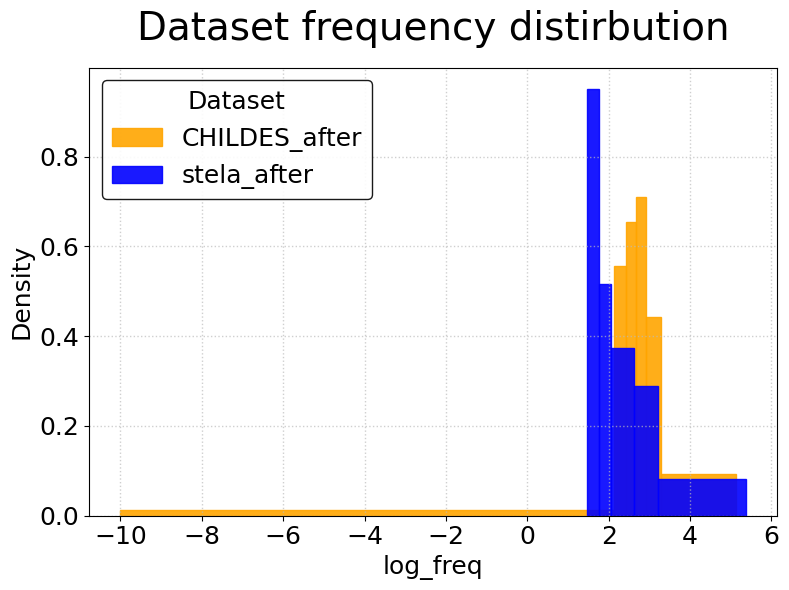

In [147]:
# plot the original distirbution
dataframes = {"CHILDES_after": human_cdi, "stela_after": stela_cdi}
# Test both plot types
plot_distributions(dataframes, column="log_freq", bin_header="bin_nb", kind="hist", title="Dataset frequency distirbution")

In [ ]:
# plot the original distirbution
dataframes = {"CHILDES_before": childes, "child_before": child_realistic, "stela_before": stela}
# Test both plot types
plot_distributions(dataframes, "log_freq", kind="hist", title="Dataset frequency distirbution")

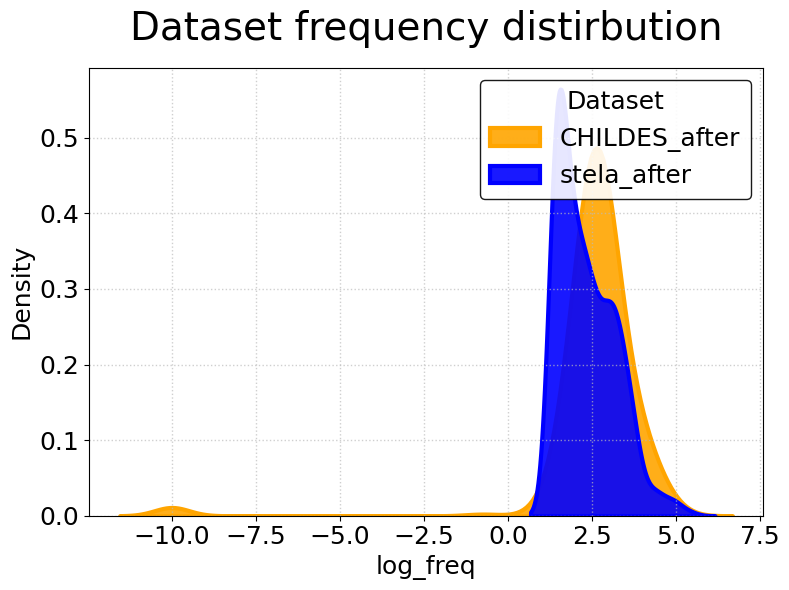

In [109]:
# plot the original distirbution
dataframes = {"CHILDES_after": human_cdi, "stela_after": stela_cdi}
# Test both plot types
plot_distributions(dataframes, "log_freq", kind="kde", title="Dataset frequency distirbution")

,word,word_length,POS,category,8,9,10,11,12,13,14,15,16,17,18,count,freq,bin_nb,log_freq
0,i,1,PRON,pronouns,0.02,0.00,0.04,0.02,0.02,0.02,0.02,0.06,0.08,0.08,0.07,271745,16989.392922,5.0,4.230178
1,tv,2,NOUN,furniture_rooms,0.02,0.01,0.01,0.02,0.02,0.02,0.02,0.09,0.11,0.11,0.12,1290,80.650304,1.0,1.906606
2,airplane,8,NOUN,vehicles,0.01,0.00,0.01,0.03,0.03,0.04,0.04,0.10,0.22,0.20,0.30,1197,74.835980,1.0,1.874110
3,all,3,PRON,quantifiers,0.00,0.01,0.01,0.01,0.01,0.01,0.02,0.04,0.05,0.04,0.09,64424,4027.763711,5.0,3.605064
4,animal,6,NOUN,animals,0.01,0.01,0.01,0.01,0.02,0.01,0.02,0.04,0.05,0.09,0.10,1875,117.224279,2.0,2.069018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,you,3,PRON,pronouns,0.00,0.01,0.02,0.02,0.02,0.02,0.02,0.05,0.06,0.08,0.09,745230,46591.493081,5.0,4.668307
356,your,4,PRON,pronouns,0.00,0.01,0.00,0.02,0.01,0.01,0.02,0.02,0.01,0.03,0.03,131689,8233.145649,5.0,3.915566
357,yucky,5,ADJ,descriptive_words,0.01,0.01,0.01,0.03,0.03,0.05,0.04,0.08,0.17,0.17,0.22,844,52.766556,1.0,1.722359
358,zipper,6,PROPN,clothing,0.01,0.00,0.01,0.02,0.01,0.01,0.02,0.03,0.03,0.07,0.09,240,15.004708,0.0,1.176228


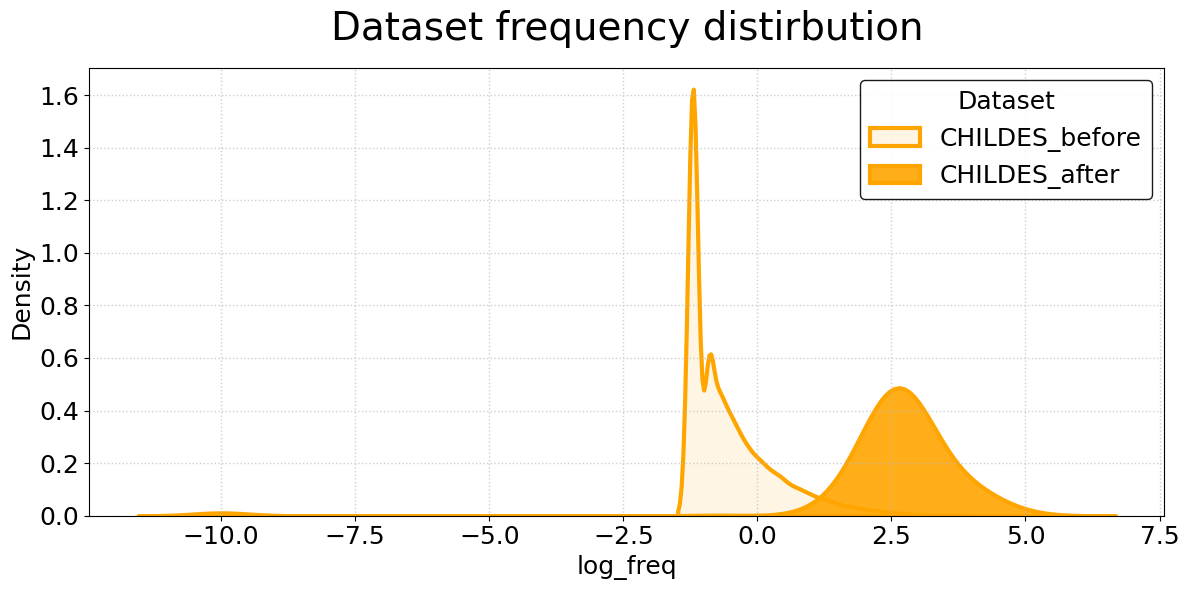

In [102]:
# plot the original distirbution
dataframes = {
    "CHILDES_before": childes,
    "CHILDES_after": human_cdi,
}
# Test both plot types
plot_distributions(dataframes, "log_freq", kind="kde", title="Dataset frequency distirbution")

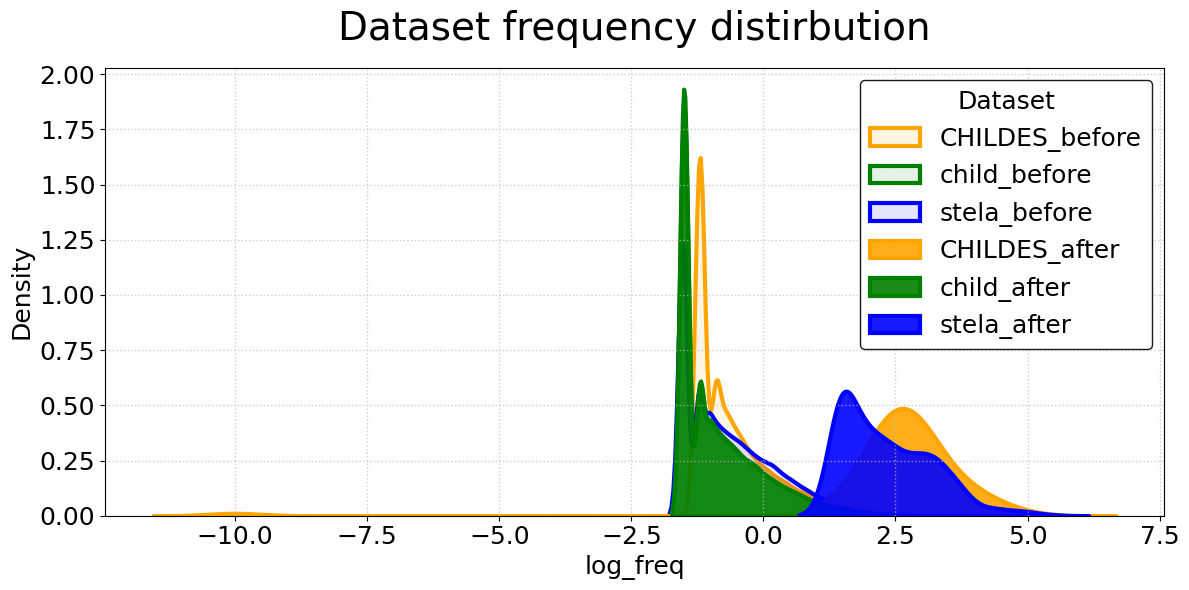

In [101]:
# plot the original distirbution
dataframes = {
    "CHILDES_before": childes,
    "child_before": child_realistic,
    "stela_before": stela,
    "CHILDES_after": human_cdi,
    "child_after": realistic_cdi,
    "stela_after": stela_cdi,
}
# Test both plot types
plot_distributions(dataframes, "log_freq", kind="kde", title="Dataset frequency distirbution")

# test CDI thresholds

In [82]:
# load raw data
raw_data_path = "/Users/jliu/workspace/lexical_bencmark/dataset/metric_CDI_threshold_test.csv"
CDI_path = "/Users/jliu/workspace/lexical_bencmark/dataset/human_CDI.csv"
raw_data = pd.read_csv(raw_data_path)
human = pd.read_csv(CDI_path)
df = raw_data.dropna()
# Sort by month and combine dataset + model_type for labels
df = df.sort_values("month")


In [158]:
def calculate_stat(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    # Group by x_col and calculate statistics
    stats = df.groupby(x_col)[y_col].agg([("mean", "mean"), ("std", "std"), ("count", "count")]).reset_index()

    # Calculate 95% confidence interval
    stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])

    return stats


def plot_combined_cdi_curves(human_cdi_path: Path, threshold_path: Path) -> plt.Figure:
    """Plot human CDI development and threshold curves in the same figure."""
    # Create single figure
    fig, ax = plt.subplots(figsize=PlotSettings.DEFAULTS["figsize"])

    # First plot the threshold curves
    df_threshold = pd.read_csv(threshold_path)
    threshold_cols = [col for col in df_threshold.columns if col.startswith("threshold_")]

    threshold_colors = PlotSettings.get_color_palette(len(threshold_cols))

    # Plot threshold curves
    for threshold, color in zip(threshold_cols, threshold_colors):
        stats = calculate_stat(df_threshold, "month", threshold)
        threshold_value = threshold.split("_")[1]

        ax.plot(stats["month"], stats["mean"], label=f"CHILDES (Threshold {threshold_value})", color=color, linewidth=PlotSettings.DEFAULTS["linewidth"], linestyle="--")

        ax.fill_between(stats["month"], stats["mean"] - stats["ci"], stats["mean"] + stats["ci"], alpha=0.1, color=color)

    # Plot human CDI development
    df_human = pd.read_csv(human_cdi_path)
    month_cols = [col for col in df_human.columns if (str(col).strip().isnumeric() and int(str(col).strip()) >= 16 and int(str(col).strip()) <= 30)]
    month_cols.sort(key=lambda x: int(x))

    monthly_means = df_human[month_cols].mean()
    monthly_std = df_human[month_cols].std()
    months = [int(col) for col in month_cols]

    # Plot human data
    human_color = "#FF0000"  # Red for human data
    ax.plot(months, monthly_means.values, linewidth=PlotSettings.DEFAULTS["linewidth"], color=human_color, marker="o", label="Human CDI", linestyle="-")

    # Add human confidence interval
    ci = 1.96 * monthly_std / np.sqrt(len(df_human))
    ax.fill_between(months, monthly_means - ci, monthly_means + ci, alpha=0.2, color=human_color)

    # Apply styling
    ax.set_xlabel("Month", fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    ax.set_ylabel("CDI Score", fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    ax.legend(
        fontsize=PlotSettings.DEFAULTS["label_fontsize"], bbox_to_anchor=(1.05, 1), loc="upper left", title="Data Sources", title_fontsize=PlotSettings.DEFAULTS["label_fontsize"]
    )

    # Apply PlotSettings style
    PlotSettings.apply_style_to_axis(ax, "CDI count-threshold")

    plt.tight_layout()
    return fig


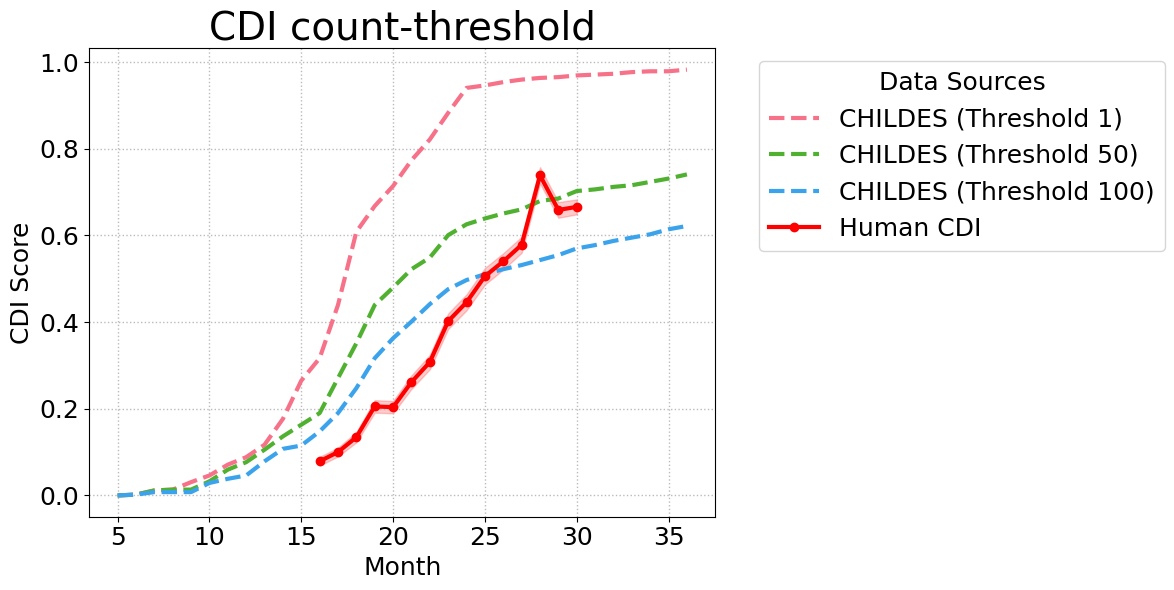

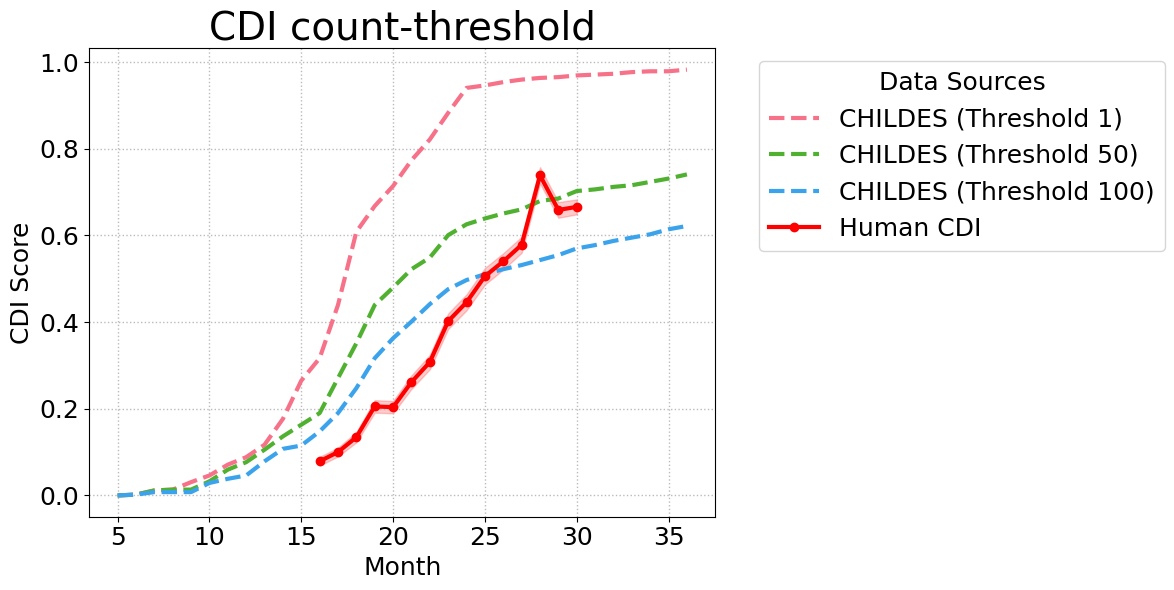

In [159]:
human_cdi_path = Path(CDI_path)
threshold_path = Path("/Users/jliu/workspace/lexical_bencmark/dataset/metric_CDI_threshold_test.csv")
# Create the combined plot
plot_combined_cdi_curves(human_cdi_path, threshold_path)


# Load file

In [160]:
# load raw data
raw_data_path = "/Users/jliu/workspace/lexical_bencmark/dataset/metric_1000_3_new.csv"
raw_data = pd.read_csv(raw_data_path)
df = raw_data.dropna()
# Sort by month and combine dataset + model_type for labels
df = df.sort_values("month")
df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"


In [89]:
df

,Unnamed: 0,month,type_token_ratio,rej_type_rate,rej_token_rate,CDI,word_num,temp,dataset,chunk,model_type,condition
2,2,7,0.247167,0.279707,0.140500,0.007678,1323,1.0,CHILDES,0,human,CHILDES(human)
70,2,7,0.345500,0.077001,0.030167,0.000000,1323,1.0,child,0,trans,child(trans)
69,1,7,0.193000,0.054337,0.016333,0.000000,1323,0.6,child,0,trans,child(trans)
68,0,7,0.110667,0.049767,0.011000,0.000000,1323,0.3,child,0,trans,child(trans)
67,3,7,0.608333,0.366777,0.224167,0.000000,1323,1.5,child,0,LSTM,child(LSTM)
...,...,...,...,...,...,...,...,...,...,...,...,...
435,3,36,0.677732,0.306563,0.207545,0.000000,299537,1.5,child,0,LSTM,child(LSTM)
436,0,36,0.160136,0.000316,0.000064,0.000000,299537,0.3,child,0,trans,child(trans)
437,1,36,0.256564,0.001406,0.000339,0.000000,299535,0.6,child,0,trans,child(trans)
846,2,36,0.548060,0.014090,0.007878,0.000000,299522,1.0,stela,0,trans,stela(trans)


# Core metrics

In [137]:
# load and merge stat in different conditions
def load_df(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Load and aggregate data based on metric while handling duplicates."""
    # Filter temperature
    df = df[df["temp"] == 1.0].copy()

    # Create condition column if not exists
    if "condition" not in df.columns:
        df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    if metric != "CDI":
        # First handle null values appropriately
        df[metric] = df[metric].fillna(method="ffill")

        # Group by month and condition to handle duplicates
        df = (
            df.groupby(["condition", metric]).agg({"dataset": "first", "model_type": "first", "temp": "first", "word_num": "mean", "chunk": "first", "month": "last"}).reset_index()
        )

    return df


def calculate_statistics(df: pd.DataFrame, group_header: str, x_header: str, y_header: str) -> pd.DataFrame:
    """Calculate mean, standard deviation, and confidence intervals."""
    stats = df.groupby([group_header, x_header])[y_header].agg(["mean", "std", "count"]).reset_index()

    # Calculate 95% confidence interval
    stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    return stats


def plot_condition_curve(subset: pd.DataFrame, condition: str, x_header: str, plot_settings: PlotSettings) -> None:
    """Plot curve for a single condition with confidence interval."""
    # load files
    color_dict = plot_settings.COLORS
    plt.plot(
        subset[x_header],
        subset["mean"],
        label=condition,
        color=color_dict[condition.split("(")[0]],
        linestyle=plot_settings.LINESTYLES.get(extract_style(condition), "-"),
        linewidth=plot_settings.DEFAULTS["linewidth"],
    )
    plt.fill_between(subset[x_header], subset["mean"] - subset["ci"], subset["mean"] + subset["ci"], color=color_dict[condition.split("(")[0]], alpha=0.2)


def plot_curves(df: pd.DataFrame, x_header: str, y_header: str, group_header: str, y_lim: list[float] = [0, 1]) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    # Initial plot configuration
    PlotSettings.configure_plot()

    # Calculate statistics
    df_stats = calculate_statistics(df, group_header, x_header, y_header)
    # Get unique conditions and their color mapping
    unique_conditions = df_stats[group_header].unique()
    # Plot each condition
    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_curve(subset, condition, x_header, PlotSettings)

    # Configure plot aesthetics
    plt.ylim(y_lim)
    plt.xlabel(x_header, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_header, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    PlotSettings.configure_legend()

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_41597/223420078.py:44: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")


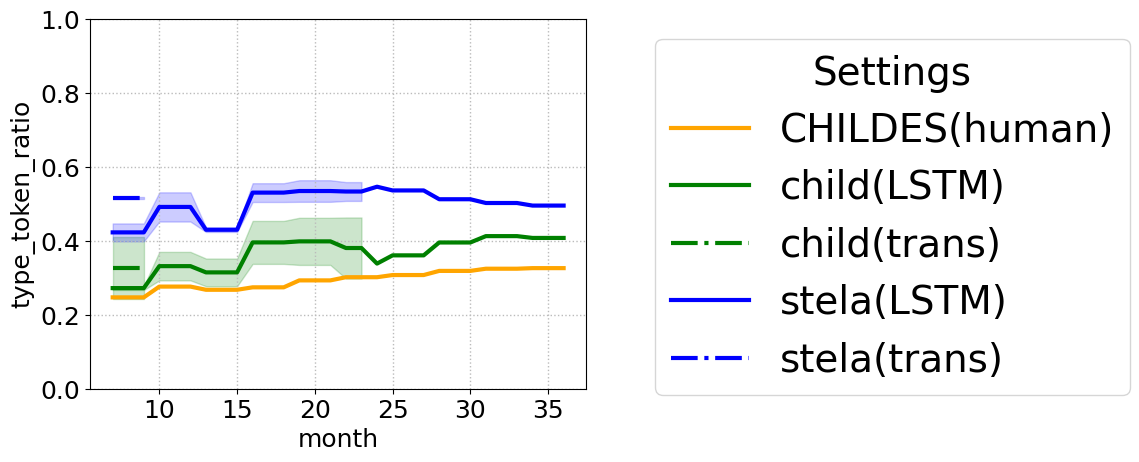

In [161]:
# Usage
x_header = "month"
y_header = "type_token_ratio"
group_header = "condition"
sel_df = load_df(df, metric=y_header)
plot_curves(sel_df, x_header, y_header, group_header)

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_41597/223420078.py:44: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")


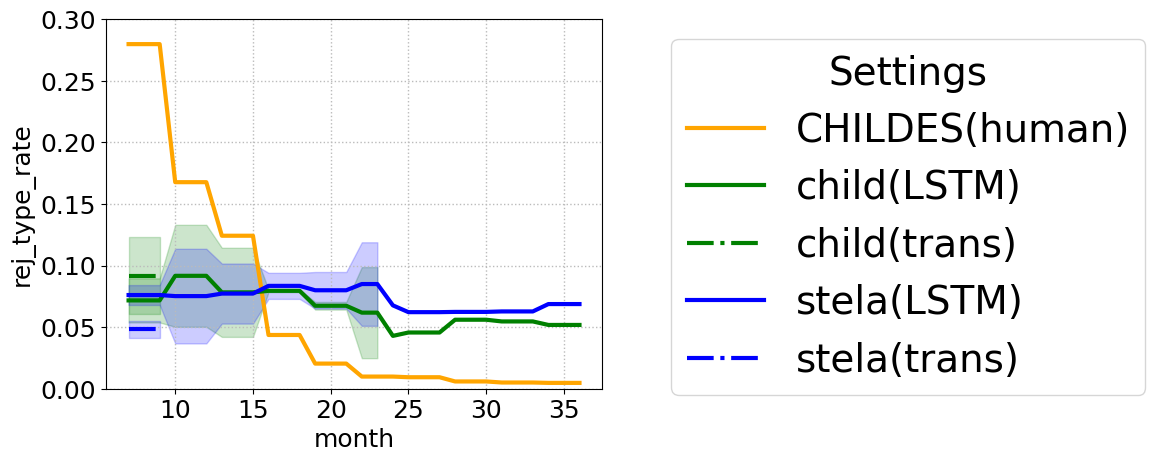

In [162]:
# Usage
x_header = "month"
y_header = "rej_type_rate"
group_header = "condition"
sel_df = load_df(df, metric=y_header)
fig = plot_curves(sel_df, x_header, y_header, group_header, y_lim=[0, 0.3])

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_41597/223420078.py:44: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")


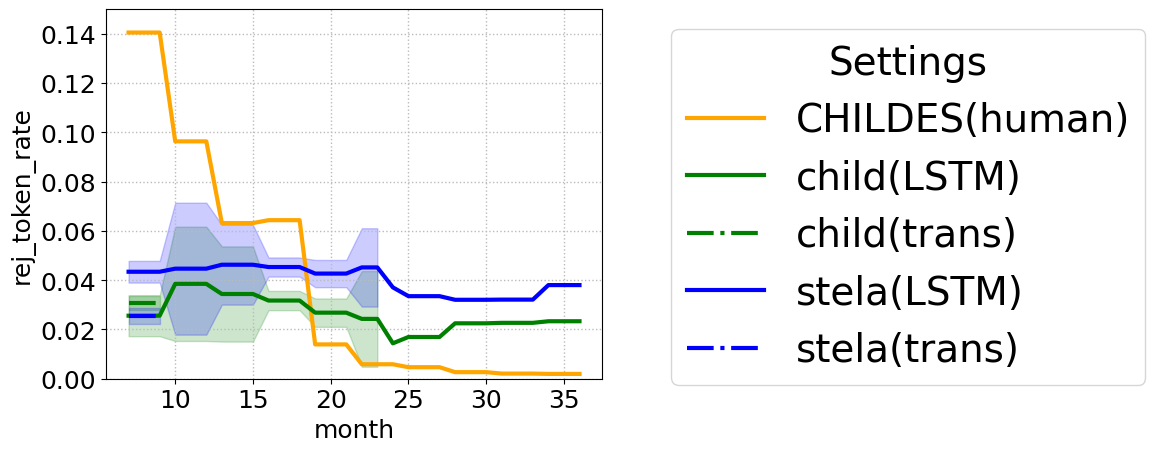

In [163]:
# Usage
x_header = "month"
y_header = "rej_token_rate"
group_header = "condition"
sel_df = load_df(df, metric=y_header)
fig = plot_curves(sel_df, x_header, y_header, group_header, y_lim=[0, 0.15])

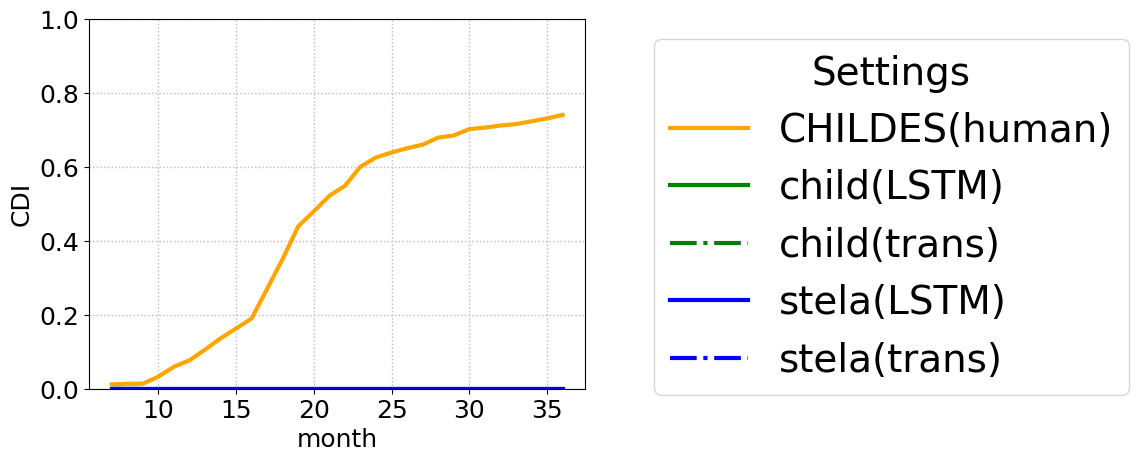

In [164]:
# Usage
x_header = "month"
y_header = "CDI"
group_header = "condition"
sel_df = load_df(df, metric=y_header)
fig = plot_curves(sel_df, x_header, y_header, group_header)

# Temperature trade-off 

In [165]:
@dataclass
class PlotConfig:
    """Configuration for plot styling"""

    color_dict: dict[str, str]
    marker_size: int = 8
    line_style: str = "--"
    font_size: int = 12
    grid_color: str = "#bbbbbb"
    grid_style: str = ":"


def load_and_process_data(file_path: Path) -> pd.DataFrame:
    """Load and process the CSV data with averaging across months"""
    df = pd.read_csv(file_path)

    # Replace 'trans' with 'Transformer' for consistency
    df["model_type"] = df["model_type"].replace("trans", "Transformer")

    # Remove rows with null values in important columns
    df = df.dropna(subset=["CDI", "type_token_ratio", "rej_type_rate"])

    # Group by relevant columns and calculate mean
    grouped_df = (
        df.groupby(["model_type", "dataset", "temp"])
        .agg({"type_token_ratio": "mean", "rej_type_rate": "mean", "rej_token_rate": "mean", "CDI": "mean", "word_num": "mean"})
        .reset_index()
    )

    return grouped_df


def load_df(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Load and aggregate data based on metric while handling duplicates."""
    # Filter temperature
    df = df[df["temp"] == 1.0].copy()

    # Create condition column if not exists
    if "condition" not in df.columns:
        df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    if metric != "CDI":
        # First handle null values appropriately
        df[metric] = df[metric].fillna(method="ffill")

        # Group by month and condition to handle duplicates
        df = df.groupby(["month", "condition", metric]).agg({"dataset": "first", "model_type": "first", "temp": "first", "word_num": "mean", "chunk": "first"}).reset_index()

    return df


def plot_model_data(data: pd.DataFrame, metric: str, model_type: str, dataset: str, config: PlotConfig) -> None:
    """Plot data for a specific model and dataset"""
    model_data = data[(data["model_type"] == model_type) & (data["dataset"] == dataset)].sort_values("temp")

    if model_data.empty:
        return

    plt.plot(
        model_data["CDI"], model_data[metric], marker="o", linestyle=config.line_style, color=config.color_dict[model_type], label=f"{model_type}", markersize=config.marker_size
    )

    # Add temperature labels
    for x, y, temp in zip(model_data["CDI"], model_data[metric], model_data["temp"]):
        plt.text(x, y, f"{temp:.1f}", fontsize=config.font_size, ha="right", va="bottom")


def create_temp_tradeoff_plot(file_path: Path, metric: str, dataset: str = "child", y_lim: list[float] = [0, 1], x_lim: list[float] = [0, 1]) -> None:
    """Create temperature trade-off plot"""
    config = PlotConfig(color_dict={"LSTM": "#ff9999", "Transformer": "#8B4513", "human": "gold"})

    data = load_and_process_data(file_path)

    # Print available datasets and model types for debugging
    print("Available datasets:", data["dataset"].unique())
    print("Available model types:", data["model_type"].unique())

    # Plot model data for LSTM and Transformer
    for model in ["LSTM", "Transformer"]:
        plot_model_data(data, metric, model, dataset, config)

    # Plot human data point
    human_data = data[(data["model_type"] == "human")]
    if not human_data.empty:
        plt.scatter(human_data["CDI"], human_data[metric], color=config.color_dict["human"], label="human", s=config.marker_size * 10)

        # Add 'human' label
        for x, y in zip(human_data["CDI"], human_data[metric]):
            plt.text(x, y, "human", fontsize=config.font_size, ha="right", va="bottom")
        print("Finished plotting human")
    plt.xlabel("CDI", fontsize=15)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=15)
    plt.xlim(x_lim)
    plt.ylim(y_lim)
    plt.legend()


Available datasets: ['child' 'stela' 'CHILDES']
Available model types: ['LSTM' 'Transformer' 'human']
Finished plotting human


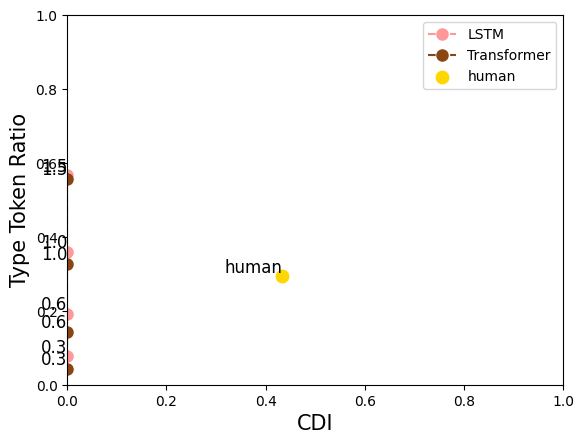

In [166]:
create_temp_tradeoff_plot(raw_data_path, "type_token_ratio")

# Extrapolated metrics

Fitting Results:
Target X: 32.36
Steepness (k): 0.1514
Midpoint (x0): 23.2554


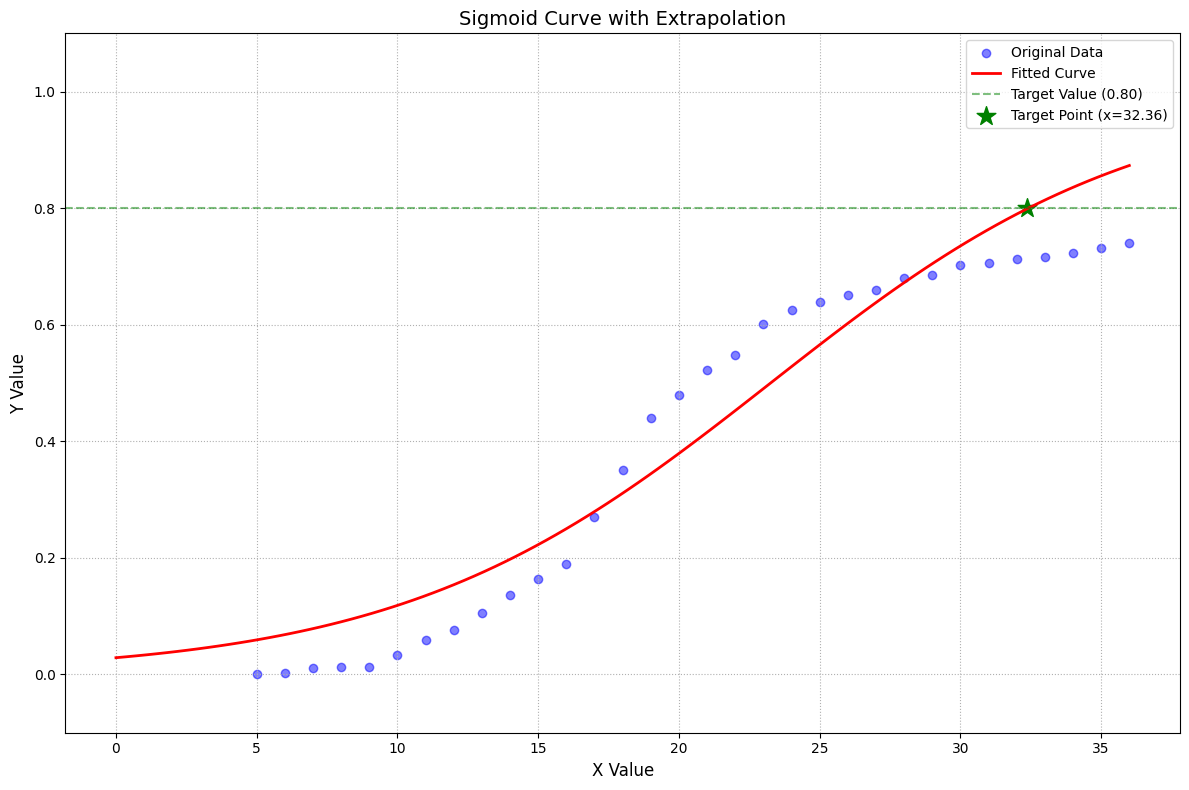

In [155]:
from scipy.optimize import curve_fit


class SigmoidFitter:
    """Fit and plot sigmoid curves with extrapolation to target value."""

    def __init__(self, x_data: list[float], y_data: list[float], target_y: float) -> None:
        """Initialize the sigmoid fitter with data and target."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)
        self.target_y = target_y
        self.params: dict[str, t.Any] = {}

    def sigmoid(self, x: np.ndarray, k: float, x0: float) -> np.ndarray:
        """
        Compute normalized sigmoid function: 1/(1 + exp(-k*(x-x0)))

        Args:
            x: Input values
            k: Steepness of the curve
            x0: x-value of sigmoid midpoint
        Returns:
            y: Values in range [0,1]
        """
        return 1 / (1 + np.exp(-k * (x - x0)))

    def estimate_initial_params(self) -> tuple[list[float], tuple[tuple[float, float], ...]]:
        """Estimate initial parameters and bounds for curve fitting."""
        # Estimate x0 (midpoint)
        y_mid = (max(self.y_data) - min(self.y_data)) / 2 + min(self.y_data)
        x0_init = self.x_data[np.argmin(np.abs(self.y_data - y_mid))]

        # Estimate k (steepness)
        mid_idx = np.argmin(np.abs(self.x_data - x0_init))
        if mid_idx > 0 and mid_idx < len(self.x_data) - 1:
            dy = self.y_data[mid_idx + 1] - self.y_data[mid_idx - 1]
            dx = self.x_data[mid_idx + 1] - self.x_data[mid_idx - 1]
            k_init = (dy / dx) * 4  # Scale factor for sigmoid shape
        else:
            k_init = 0.1

        # Initial parameter guesses
        p0 = [k_init, x0_init]

        # Parameter bounds
        bounds = (
            (0.001, 2.0),  # k bounds: shallow to steep
            (min(self.x_data), max(self.x_data) * 1.5),  # x0 bounds
        )

        return p0, bounds

    def fit_sigmoid(self) -> dict[str, float]:
        """Fit sigmoid and find target x value."""
        # Get initial parameters and bounds
        p0, bounds = self.estimate_initial_params()

        # Fit sigmoid curve with bounds and initial guesses
        popt, _ = curve_fit(self.sigmoid, self.x_data, self.y_data, p0=p0, bounds=bounds, maxfev=100000, method="trf")

        # Generate fitted points with finer resolution
        x_fit = np.linspace(0, max(self.x_data), 100)
        y_fit = self.sigmoid(x_fit, *popt)

        # Extrapolate if needed
        if max(self.y_data) < self.target_y:
            while y_fit[-1] < self.target_y:
                next_x = x_fit[-1] + (x_fit[1] - x_fit[0])
                x_fit = np.append(x_fit, next_x)
                y_fit = np.append(y_fit, self.sigmoid(next_x, *popt))

                if y_fit[-1] >= self.target_y or len(x_fit) > 1000:
                    break

        # Find target point
        target_y_index = np.argmin(np.abs(y_fit - self.target_y))
        target_x = x_fit[target_y_index]

        self.params = {"x_fit": x_fit, "y_fit": y_fit, "target_x": target_x, "k": popt[0], "x0": popt[1]}

        return {"target_x": target_x, "k": popt[0], "x0": popt[1]}

    def plot_curve(self, title: str = "Sigmoid Curve with Extrapolation", output_path: Path | None = None) -> None:
        """Plot the fitted sigmoid curve with extrapolation."""
        if not self.params:
            self.fit_sigmoid()

        plt.figure(figsize=(12, 8))

        # Plot original data points
        plt.scatter(self.x_data, self.y_data, color="blue", alpha=0.5, label="Original Data")

        # Plot fitted curve
        plt.plot(self.params["x_fit"], self.params["y_fit"], "r-", label="Fitted Curve", linewidth=2)

        # Plot target line and point
        plt.axhline(y=self.target_y, color="green", linestyle="--", alpha=0.5, label=f"Target Value ({self.target_y:.2f})")
        plt.scatter(self.params["target_x"], self.target_y, color="green", marker="*", s=200, label=f"Target Point (x={self.params['target_x']:.2f})")

        # Customize plot
        plt.grid(True, linestyle=":")
        plt.title(title, fontsize=14)
        plt.xlabel("X Value", fontsize=12)
        plt.ylabel("Y Value", fontsize=12)
        plt.legend(fontsize=10)
        plt.ylim(-0.1, 1.1)  # Set y-axis limits to show full [0,1] range

        plt.tight_layout()
        if output_path:
            plt.savefig(output_path, bbox_inches="tight", dpi=300)
            plt.close()
        else:
            plt.show()


def test_sigmoid_fitter() -> None:
    """Test the SigmoidFitter class with sample data."""
    # Generate sample data

    frame = pd.read_csv(threshold_path)
    x_data = frame["month"]
    y_data = frame["threshold_50"]

    target_y = 0.8

    # Create and fit sigmoid
    fitter = SigmoidFitter(x_data, y_data, target_y)
    results = fitter.fit_sigmoid()

    print("Fitting Results:")
    print(f"Target X: {results['target_x']:.2f}")
    print(f"Steepness (k): {results['k']:.4f}")
    print(f"Midpoint (x0): {results['x0']:.4f}")

    # Plot results
    fitter.plot_curve()


if __name__ == "__main__":
    test_sigmoid_fitter()

# Case study

## scatter plot of different vocab distr

In [114]:
def load_count(freq_ROOT: str) -> list:
    all_count = []
    # load all the generated sets
    files = os.listdir(freq_ROOT)
    files = sorted(files)
    for file in files:
        if file.endswith(".csv"):
            word_count = TokenCount()
            word_count.df = pd.read_csv(f"{freq_ROOT}{file}")
            word_count.name = file[:-4].split("_")[-1]
            all_count.append(word_count)
    return all_count


# load data recursively
def load_files(freq_ROOT: str) -> list:
    all_count = []
    # load all the generated sets
    files = os.listdir(freq_ROOT)
    files = sorted(files)
    for file in files:
        if file.endswith(".csv"):
            word_count = TokenCount()
            word_count.df = pd.read_csv(f"{freq_ROOT}{file}")
            word_count.name = file[:-4].split("_")[-1]
            all_count.append(word_count)

    # divide into different types of sets
    gen_count = []
    unwanted_lst = ["train", "child", "adult"]
    for tc in all_count:
        if tc.name not in unwanted_lst:
            gen_count.append(tc)
        if tc.name == "train":
            ref_count = tc
        else:
            pass
    return all_count, ref_count, gen_count

In [116]:
def line_plot(data, fig_path: str, prompt_type: str, model: str, xlog=True, ylim=[0, 1]):
    """Generic line plotting function; data is a dictionnary associating a name with a dataframe with two columns
    (the first one for x, the second one for y)
    """
    # plt.figure(figsize=(10, 5))  # Set the size of the plot

    for key in data:
        df = data[key]
        xname = df.columns[0]
        yname = df.columns[1]
        aggregated_df = df.groupby(xname)[yname].mean().reset_index()
        if key == "ind" or key == "ood":
            linetyle = "-"
            linewidth = 3.5
        else:
            linetyle = "-"
            linewidth = 3
        plt.plot(aggregated_df[xname], aggregated_df[yname], linewidth=linewidth, linestyle=linetyle, label=key, color=color_dict[key])

    plt.xlabel(xname, fontsize=20)  # Label for the x-axis
    plt.ylabel(yname, fontsize=20)  # Label for the y-axis
    plt.ylim(ylim)
    # plt.axhline(y=0, color='red', linestyle='--',linewidth=3.5, label='y = 0')
    if xlog:
        plt.xscale("log")


def tc_plot_miss_oov_rates(ref_count: TokenCount, gen_count_list: list, set_name: str, fig_path: str, prompt_type: str, model: str, groupbin=50):
    """
     Plots three curves regarding missing words and oovs

    :param ref_count: a reference TokenCount
    :param gen_count_list: a list of generated or test TokenCount
    :param groupbin:
    :return: dataframe containing different scores
    """
    pmiss = {}
    poov = {}

    for gen_count in gen_count_list:
        msc, osc, nsc = tc_compute_miss_oov_rates(ref_count, gen_count, groupbin=groupbin)
        if set_name == "pmiss":
            pmiss[gen_count.name] = msc[["medcount", "pmiss"]]
            line_plot(pmiss, fig_path + "M.png", prompt_type, model)
        elif set_name == "oov":
            poov[gen_count.name] = osc[["medcount", "poov"]]
            line_plot(poov, fig_path + "O.png", prompt_type, model)
    return msc, osc, nsc

In [11]:
def scatter_hist_shade(ref_count: TokenCount, gen_count: TokenCount, model: str, ax, ax_histx, ax_histy, color_dict, num, log, bins=100, alpha_val=0.5):
    # Scatter plot with varying transparency (alpha) and edge color
    newdf = pd.merge(ref_count.df[["word", "count"]], gen_count.df[["word", "count"]], on="word", how="outer")
    newdf.set_index("word", inplace=True)
    newdf.columns = ["ref_count", "gen_count"]
    withoutoovdf = newdf[newdf["ref_count"].notna()]

    # Vary the transparency for each dataset
    ax.scatter(withoutoovdf["ref_count"], withoutoovdf["gen_count"], color=color_dict[num], alpha=alpha_val, label=f"{num}x")

    maxx = max(withoutoovdf["gen_count"])
    ax.plot([0, maxx], [0, maxx], color="r", alpha=1)

    # Plot the missing word rates by frequency
    msc, osc, nsc = tc_compute_miss_oov_rates(ref_count, gen_count, groupbin=50)

    aggregated_df_miss = msc.groupby("medcount")["pmiss"].mean().reset_index()
    ax_histx.plot(aggregated_df_miss["medcount"], aggregated_df_miss["pmiss"], linewidth=3.5, linestyle="-", color=color_dict[num])

    # ax_histx.invert_yaxis()

    aggregated_df_oov = osc.groupby("medcount")["poov"].mean().reset_index()
    ax_histy.plot(aggregated_df_oov["poov"], aggregated_df_oov["medcount"], linewidth=3.5, linestyle="-", color=color_dict[num])

    # ax_histy.invert_xaxis()

    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")
        # ax_histx.set_yscale("log")
        ax_histy.set_yscale("log")
        ax_histx.set_xscale("log")
        # ax_histy.set_xscale("log")

    # Set axis range for histograms (side bars)
    ax_histx.set_ylim(0, 1)  # Set x-axis range for the top histogram
    ax_histy.set_xlim(0, 1)  # Set y-axis range for the left histogram
    # save the figure to the required directory
    plt.savefig(Path(fig_ROOT) / f"distr_{model[:5]}_{gen_count.name}.png", dpi=300, bbox_inches="tight")
    return newdf, maxx


/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  newdf['correct'].fillna(newdf['ref_correct'], inplace=True)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting',

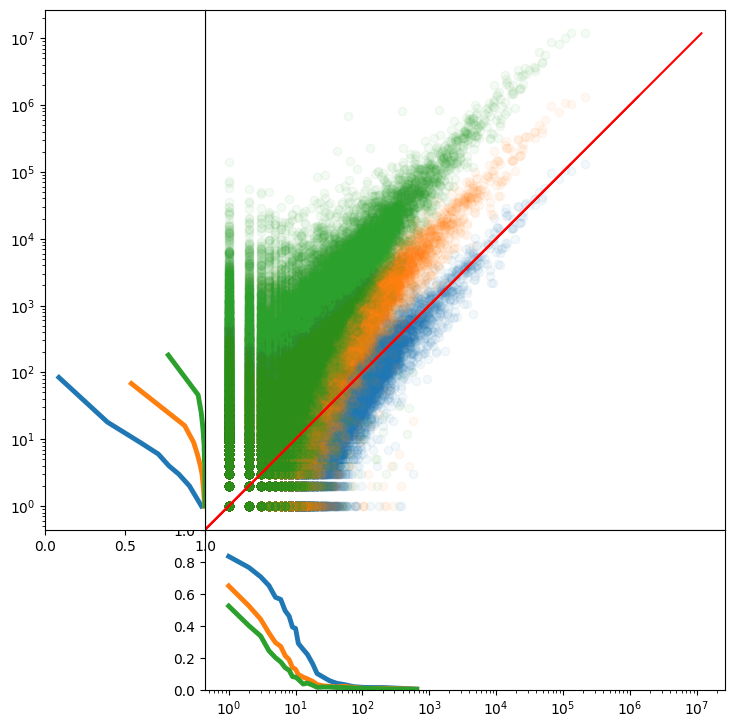

In [12]:
filename_lst = ["1", "10", "100"]
prompt_type = "unprompted"
color_dict = {
    "1": "#1f77b4",  # Blue
    "10": "#ff7f0e",  # Orange
    "100": "#2ca02c",  # Green
}

log = True
model = "LSTM"

# Create the figure once, outside the loop
fig = plt.figure(figsize=(8, 8))

# Axes locations for subplots, we will reuse them across the loop
left, width = 0.3, 0.65
bottom, height = 0.1, 0.65
spacing = 0

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom - spacing - 0.2, width, 0.2]
rect_histy = [left - spacing - 0.2, bottom, 0.2, height]

# Create ax once, and reuse for each dataset
ax = fig.add_axes(rect_scatter)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)

diag_lines = {}
# Loop over each dataset
for idx, filename in enumerate(filename_lst):
    freq_ROOT = f"{ROOT}/datasets/processed/freq/{prompt_type}_{model}_400_{filename}/"
    all_count, ref_count, gen_count_lst = load_files(freq_ROOT)

    # Set alpha transparency value: Start with 0.8 and reduce for each subsequent dataset
    alpha_val = 0.05
    newdf, maxx = scatter_hist_shade(ref_count, gen_count_lst[0], model, ax, ax_histx, ax_histy, color_dict, filename, log, alpha_val=alpha_val)

# Add legend and display the figure

plt.show()
